# GNN Handling Data In Python

In [2]:
!python -c "import torch; print(torch.version.cuda)"

12.1


In [3]:
# Pytorch version
!python -c "import torch; print(torch.__version__)"

2.3.0+cu121


In [4]:
# Installing required packages
# To ensure compatibility with PyTorch Geometric's pre-compiled wheels for CUDA 12.x in Colab,
# it's often necessary to install a specific, known-working PyTorch version.
# We will install PyTorch 2.3.0 with CUDA 12.1 (which works with Colab's CUDA 12.8 drivers).
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0 --index-url https://download.pytorch.org/whl/cu121

# Now, install torch-scatter and torch-sparse using the correct PyG wheel links for PyTorch 2.3.0+cu121
# Use --force-reinstall in case partial installations are present.
!pip install torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.3.0+cu121.html --force-reinstall

# Finally, install torch-geometric
!pip install torch_geometric

print("\n--- Verification After Installation ---")
import torch
import torch_geometric

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA version (detected by PyTorch): {torch.version.cuda}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"torch_geometric version: {torch_geometric.__version__}")

# It's often recommended to restart the runtime after significant library installations/reinstallations.
# Go to 'Runtime' -> 'Restart runtime' if you encounter further issues.

Looking in indexes: https://download.pytorch.org/whl/cu121
Looking in links: https://data.pyg.org/whl/torch-2.3.0+cu121.html
  Using cached https://data.pyg.org/whl/torch-2.3.0%2Bcu121/torch_scatter-2.1.2%2Bpt23cu121-cp312-cp312-linux_x86_64.whl (10.9 MB)
  Using cached https://data.pyg.org/whl/torch-2.3.0%2Bcu121/torch_sparse-0.6.18%2Bpt23cu121-cp312-cp312-linux_x86_64.whl (5.1 MB)
  Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (62 kB)
  Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl.metadata (6.6 kB)
Using cached scipy-1.18.0-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (35.3 MB)
Using cached numpy-2.5.1-cp312-cp312-manylinux_2_27_x86_64.manylinux_2_28_x86_64.whl (16.7 MB)
  Attempting uninstall: torch-scatter
    Found existing installation: torch_scatter 2.1.2+pt23cu121
    Uninstalling torch_scatter-2.1.2+pt23cu121:
      Successfully uninstalled torch_scatter-2.1.2+pt23cu121
  A


--- Verification After Installation ---
PyTorch version: 2.3.0+cu121
CUDA version (detected by PyTorch): 12.1
CUDA available: True
torch_geometric version: 2.8.0


In [1]:
# Importing necessary libraries
# Here '%' is magic command that specify to show the plots ri ght after the cell that generates them.
%matplotlib inline
import torch
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.datasets import KarateClub

[transformers] Disabling PyTorch because PyTorch >= 2.4 is required but found 2.3.0+cu121
[transformers] PyTorch was not found. Models won't be available and only tokenizers, configuration and file/data utilities can be used.


In [2]:
# Loading dataset
dataset = KarateClub()

In [3]:
print(f"Dataset: {dataset}")
print("===============")
print(f"Number of graphs: {len(dataset)}") # 1 graph i.e., dataset[0]
print(f"Number of features: {dataset.num_features}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of nodes: {dataset[0].num_nodes}")
print(f"Number of edges: {dataset[0].num_edges}")
print(f"Number of edge features: {dataset.num_edge_features}")
print(f"Has selfloop: {dataset[0].has_self_loops()}")
print(f"Has isolated nodes: {dataset[0].has_isolated_nodes()}")
print(f"Is directed: {dataset[0].is_directed()}")
print(f"Edge weight: {dataset[0].edge_weight}")
print("Graph: ", dataset[0])
print("=================================")
print(f"Number of training nodes: {dataset[0].train_mask.sum()}")
print(f"Training node label rate: {int(dataset[0].train_mask.sum()) / dataset[0].num_nodes:.2f}") # ':2f' converts all on the left to 2 decimal floating number in a string format, i.e., "0.12"

Dataset: KarateClub()
Number of graphs: 1
Number of features: 34
Number of classes: 4
Number of nodes: 34
Number of edges: 156
Number of edge features: 0
Has selfloop: False
Has isolated nodes: False
Is directed: False
Edge weight: None
Graph:  Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
Number of training nodes: 4
Training node label rate: 0.12


# Node Store

In [4]:
data = dataset[0]
print(data)
data.node_stores

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


[{'x': tensor([[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]), 'edge_index': tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
           3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
           7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
          13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
          21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
          27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
          31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
          33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
    

In [6]:
# Parsing to dictionary
data.to_dict()

{'x': tensor([[1., 0., 0.,  ..., 0., 0., 0.],
         [0., 1., 0.,  ..., 0., 0., 0.],
         [0., 0., 1.,  ..., 0., 0., 0.],
         ...,
         [0., 0., 0.,  ..., 1., 0., 0.],
         [0., 0., 0.,  ..., 0., 1., 0.],
         [0., 0., 0.,  ..., 0., 0., 1.]]),
 'edge_index': tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
           1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
           3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
           7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
          13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
          21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
          27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
          31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
          33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
    

In [9]:
# Restrict height of output cell
from IPython.display import Javascript
display(Javascript('''google.colab.output.setIframeHeight(0, true, {maxHeight: 300})'''))

<IPython.core.display.Javascript object>

KarateClub dataset


*   edge_index = [2, 156]



In [12]:
edge_index = data.edge_index
edge_index

tensor([[ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,
          1,  1,  1,  1,  1,  1,  1,  2,  2,  2,  2,  2,  2,  2,  2,  2,  2,  3,
          3,  3,  3,  3,  3,  4,  4,  4,  5,  5,  5,  5,  6,  6,  6,  6,  7,  7,
          7,  7,  8,  8,  8,  8,  8,  9,  9, 10, 10, 10, 11, 12, 12, 13, 13, 13,
         13, 13, 14, 14, 15, 15, 16, 16, 17, 17, 18, 18, 19, 19, 19, 20, 20, 21,
         21, 22, 22, 23, 23, 23, 23, 23, 24, 24, 24, 25, 25, 25, 26, 26, 27, 27,
         27, 27, 28, 28, 28, 29, 29, 29, 29, 30, 30, 30, 30, 31, 31, 31, 31, 31,
         31, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 32, 33, 33, 33, 33, 33,
         33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33, 33],
        [ 1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 17, 19, 21, 31,  0,  2,
          3,  7, 13, 17, 19, 21, 30,  0,  1,  3,  7,  8,  9, 13, 27, 28, 32,  0,
          1,  2,  7, 12, 13,  0,  6, 10,  0,  6, 10, 16,  0,  4,  5, 16,  0,  1,
          2,  3,  0,  2, 30, 32, 33,  2, 33,  0,  4

In [13]:
# Printing as tensor
print(edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

# Graph Classes

In [14]:
print(f"Number of classes: {dataset.num_classes}")
print(data)

Number of classes: 4
Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


In [16]:
# To check number of classes
data.y

tensor([1, 1, 1, 1, 3, 3, 3, 1, 0, 1, 3, 1, 1, 1, 0, 0, 3, 1, 0, 1, 0, 1, 0, 0,
        2, 2, 0, 0, 2, 0, 0, 2, 0, 0])

In [17]:
data.y.shape

torch.Size([34])

# Node Features

In [18]:
data.x

tensor([[1., 0., 0.,  ..., 0., 0., 0.],
        [0., 1., 0.,  ..., 0., 0., 0.],
        [0., 0., 1.,  ..., 0., 0., 0.],
        ...,
        [0., 0., 0.,  ..., 1., 0., 0.],
        [0., 0., 0.,  ..., 0., 1., 0.],
        [0., 0., 0.,  ..., 0., 0., 1.]])

In [20]:
data.x.shape

torch.Size([34, 34])

In [26]:
# 1st row
print("1st row: ", data.x[0])
print("Last row: ", data.x[33])

1st row:  tensor([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
Last row:  tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])


# Graph Visualization

In [39]:
# Function for graph visualization
def visualize_graph(graph, color):
  plt.figure(figsize=(12, 12))
  plt.xticks([]) # Hides x axis labels
  plt.yticks([]) # Hides y axis labels
  nx.draw_networkx(graph, pos=nx.spring_layout(graph, seed=42), with_labels=False, node_color=color, cmap="Set2") # 'seed=any_number' is used to lock the randomness, means, on running the code the nodes will remain at their exact same spots.

  plt.show()

Undirected graph

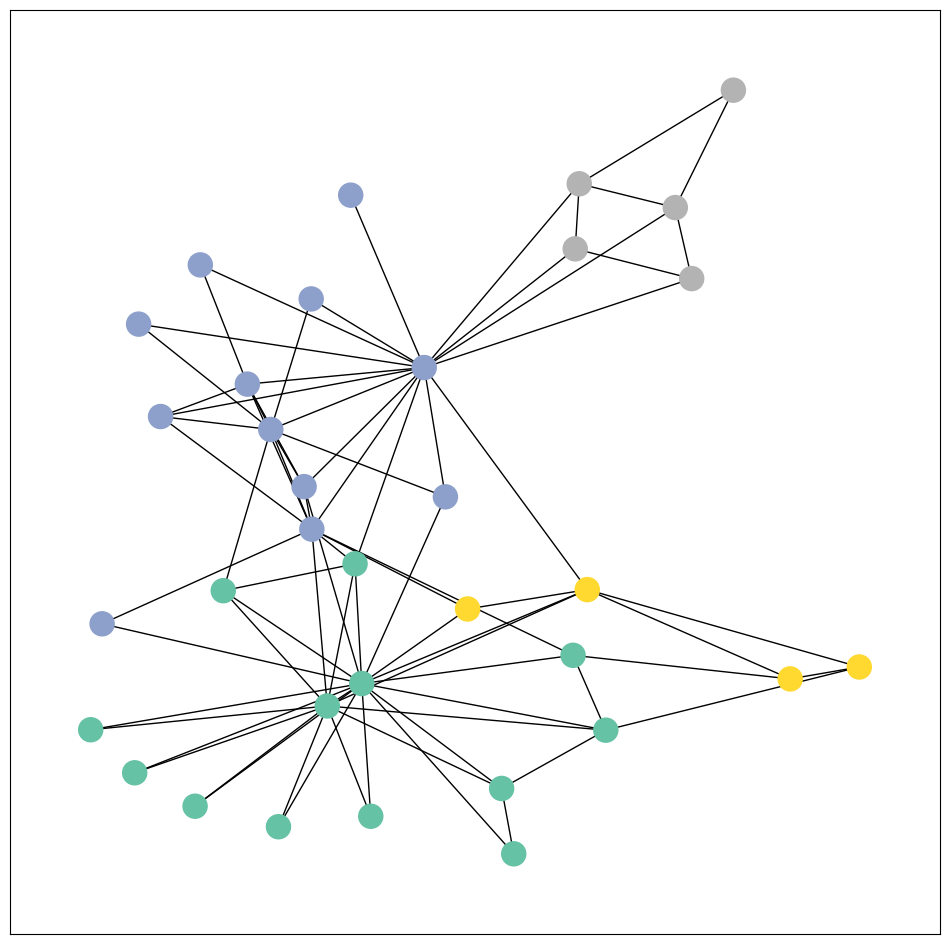

In [40]:
from torch_geometric.utils import to_networkx
karate_undirected_graph = to_networkx(data, to_undirected=True)
visualize_graph(karate_undirected_graph, color=data.y)

In [43]:
# Number of nodes
karate_undirected_graph.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33))

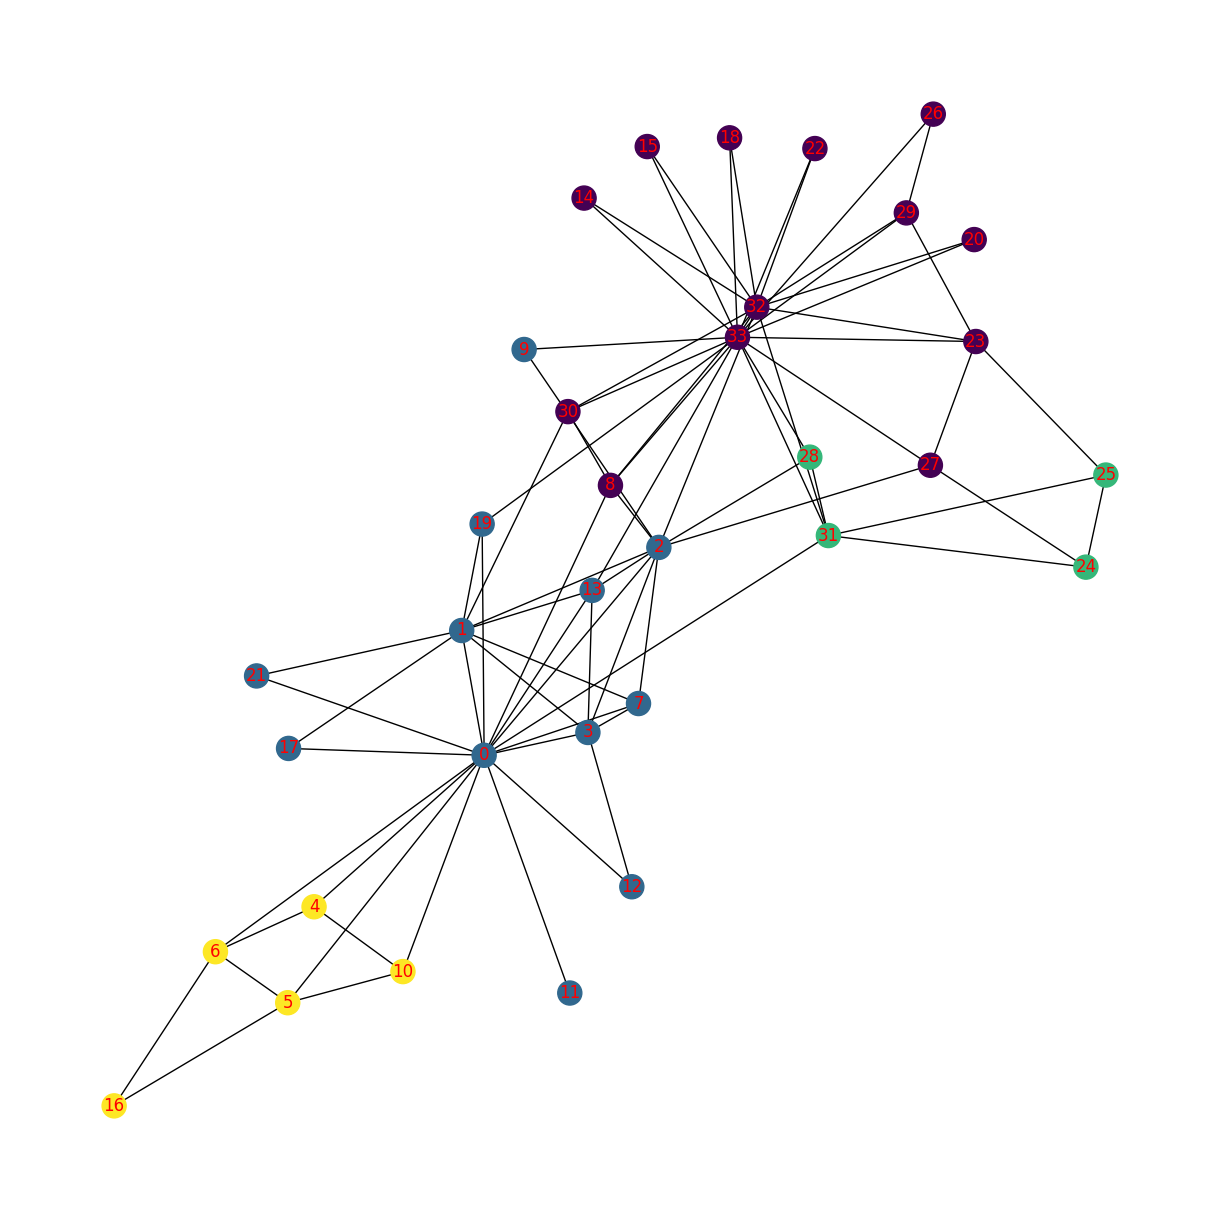

In [74]:
# Rendering the graph with labels
plt.figure(figsize=(12, 12))
nx.draw(karate_undirected_graph, cmap=plt.get_cmap("viridis"), with_labels=True, node_color=data.y, font_color="red")

In [50]:
# Number of edges
print("Number of edges in karate undirected graph: ", karate_undirected_graph.number_of_edges())
karate_undirected_graph.edges

Number of edges in karate undirected graph:  78


EdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16), (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33), (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32), (31, 33), (32, 33)])

In [64]:
# Number of nodes & degrees(a node is connected to how many other nodes)
print("Number of nodes of karate undirected graph: ", karate_undirected_graph.number_of_nodes())
karate_undirected_graph.degree

Number of nodes of karate undirected graph:  34


DegreeView({0: 16, 1: 9, 2: 10, 3: 6, 4: 3, 5: 4, 6: 4, 7: 4, 8: 5, 9: 2, 10: 3, 11: 1, 12: 2, 13: 5, 14: 2, 15: 2, 16: 2, 17: 2, 18: 2, 19: 3, 20: 2, 21: 2, 22: 2, 23: 5, 24: 3, 25: 3, 26: 2, 27: 4, 28: 3, 29: 4, 30: 4, 31: 6, 32: 12, 33: 17})

In [66]:
# Representing the graph in the matrix form
nx.to_numpy_array(karate_undirected_graph)

array([[0., 1., 1., ..., 1., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 1.],
       [0., 0., 1., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]], shape=(34, 34))

Directed graph

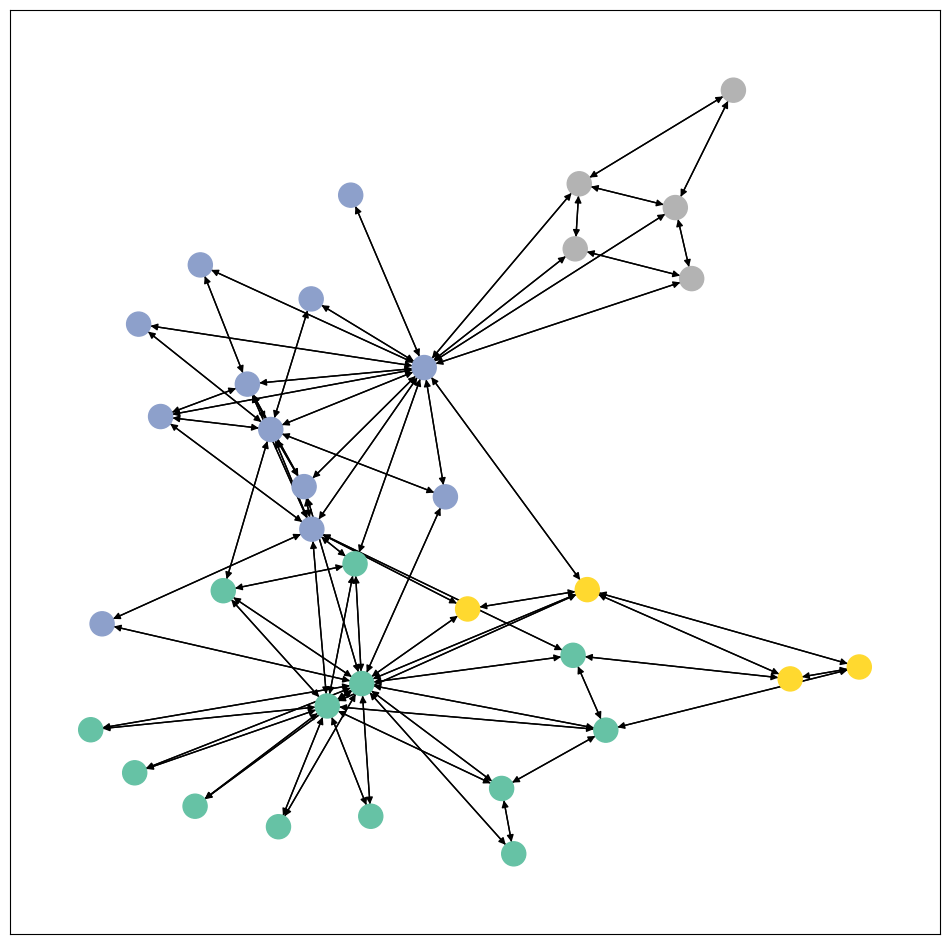

In [67]:
karate_directed_graph = to_networkx(data)
visualize_graph(karate_directed_graph, color=data.y)

In [68]:
# Number of nodes
karate_directed_graph.nodes

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33))

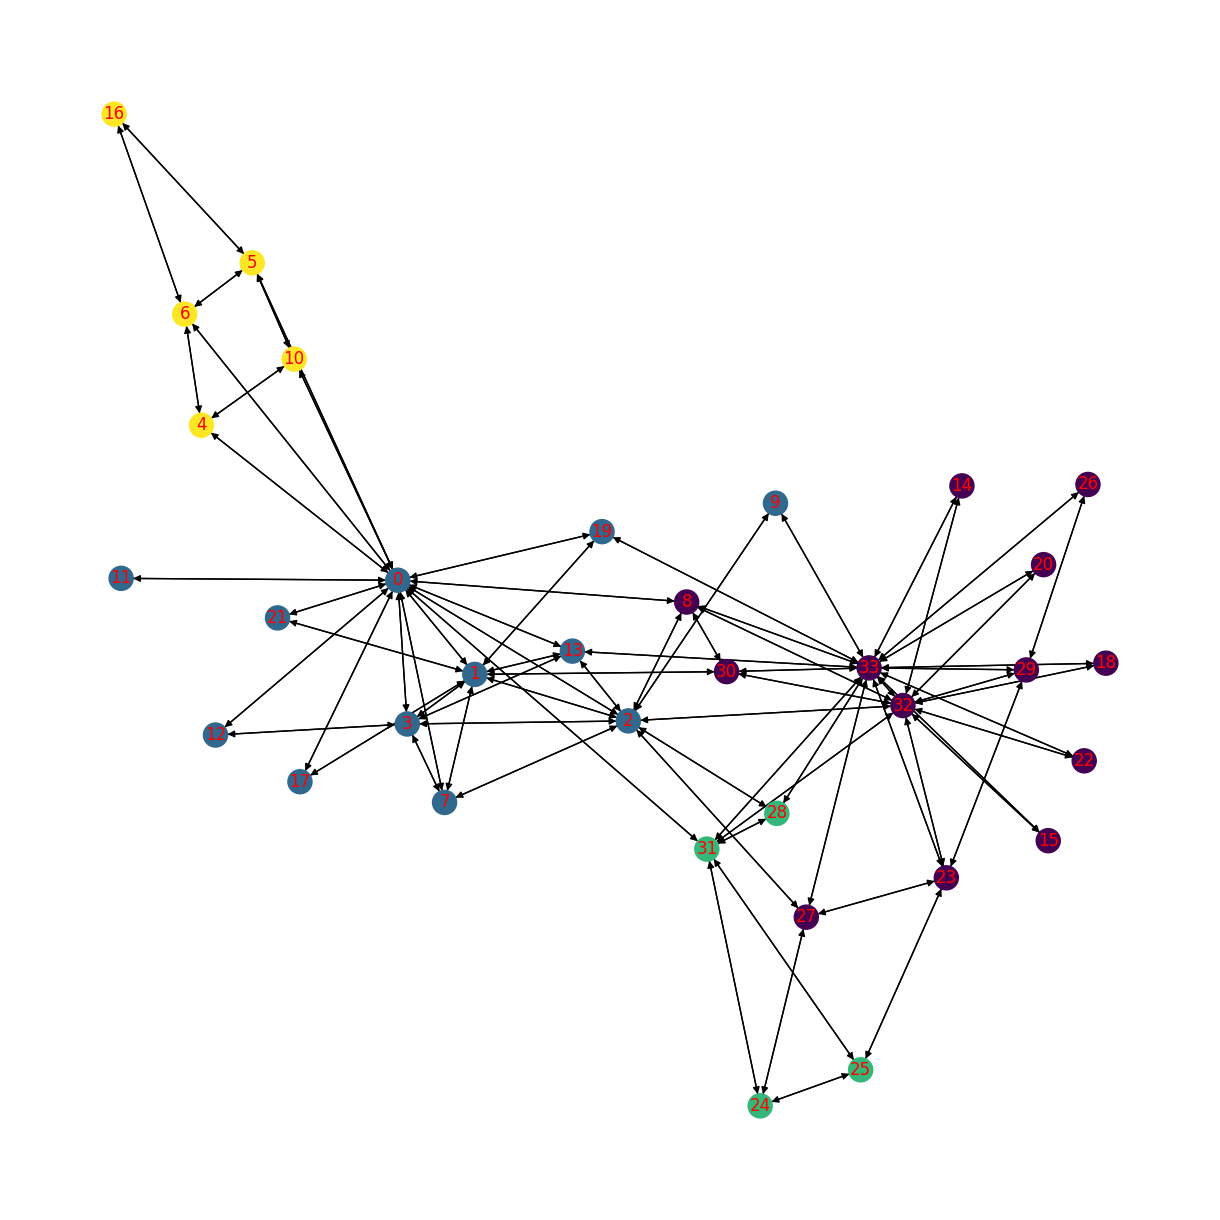

In [75]:
# Rendering the graph with labels
plt.figure(figsize=(12,12))
nx.draw(karate_directed_graph, cmap=plt.get_cmap("viridis"), with_labels=True, node_color=data.y, font_color="red")

In [70]:
# Number of edges
print("Number of edges in karate directed graph: ", karate_directed_graph.number_of_edges())
karate_directed_graph.edges

Number of edges in karate directed graph:  156


OutEdgeView([(0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8), (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31), (1, 0), (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30), (2, 0), (2, 1), (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32), (3, 0), (3, 1), (3, 2), (3, 7), (3, 12), (3, 13), (4, 0), (4, 6), (4, 10), (5, 0), (5, 6), (5, 10), (5, 16), (6, 0), (6, 4), (6, 5), (6, 16), (7, 0), (7, 1), (7, 2), (7, 3), (8, 0), (8, 2), (8, 30), (8, 32), (8, 33), (9, 2), (9, 33), (10, 0), (10, 4), (10, 5), (11, 0), (12, 0), (12, 3), (13, 0), (13, 1), (13, 2), (13, 3), (13, 33), (14, 32), (14, 33), (15, 32), (15, 33), (16, 5), (16, 6), (17, 0), (17, 1), (18, 32), (18, 33), (19, 0), (19, 1), (19, 33), (20, 32), (20, 33), (21, 0), (21, 1), (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33), (24, 25), (24, 27), (24, 31), (25, 23), (25, 24), (25, 31), (26, 29), (26, 33), (27, 2), (27, 23), (27, 24), (27, 33), (28, 

In [71]:
# Number of nodes & degrees
print("Number of nodes of karate directed graph: ", karate_directed_graph.number_of_nodes())
karate_directed_graph.degree

Number of nodes of karate directed graph:  34


DiDegreeView({0: 32, 1: 18, 2: 20, 3: 12, 4: 6, 5: 8, 6: 8, 7: 8, 8: 10, 9: 4, 10: 6, 11: 2, 12: 4, 13: 10, 14: 4, 15: 4, 16: 4, 17: 4, 18: 4, 19: 6, 20: 4, 21: 4, 22: 4, 23: 10, 24: 6, 25: 6, 26: 4, 27: 8, 28: 6, 29: 8, 30: 8, 31: 12, 32: 24, 33: 34})

In [72]:
# Representing the graph in matrix form
nx.to_numpy_array(karate_directed_graph)

array([[0., 1., 1., ..., 1., 0., 0.],
       [1., 0., 1., ..., 0., 0., 0.],
       [1., 1., 0., ..., 0., 1., 0.],
       ...,
       [1., 0., 0., ..., 0., 1., 1.],
       [0., 0., 1., ..., 1., 0., 1.],
       [0., 0., 0., ..., 1., 1., 0.]], shape=(34, 34))